In [4]:
from typing import TypedDict

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger


# 1、构建子图
# 1.1 声明子图的状态
class SubgraphState(TypedDict):
    raw_text: str  # 未清洗的文本
    stripped_text: str  # 去除首位的空格
    punctuated_text: str  # 句尾添加句号


# 1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text": stripped_text
    }


# 1.3 添加句号的节点
def subgraph_punctuated_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text": punctuated_text
    }


# 1.4 构建子图
builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuaed_node", subgraph_punctuated_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuaed_node")
builder.add_edge("subgraph_punctuaed_node", END)

subgraph = builder.compile()
res = subgraph.invoke(
    {"raw_text": " langgraph真有意思"}
)
print(res)

2026-08-05 09:07:51.850 | INFO     | __main__:subgraph_strip_node:20 - 调用子图中的strip节点
2026-08-05 09:07:51.851 | INFO     | __main__:subgraph_punctuated_node:30 - 调用子图中的punctuated节点


{'raw_text': ' langgraph真有意思', 'stripped_text': 'langgraph真有意思', 'punctuated_text': 'langgraph真有意思。'}


In [6]:
# 2、 构建父图
# 2.1 声明状态
class ParentState(TypedDict):
    input_text: str
    cleaned_text: str


# 2.2 声明节点 => 调用子图节点
def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]
    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }


# 2.3 构建父图
parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node("call_subgraph", call_subgraph)
parent_builder.add_edge(START, "call_subgraph")
parent_builder.add_edge("call_subgraph", END)

parent_graph = parent_builder.compile()

# 2。4 调用父图
res = parent_graph.invoke({"input_text": "  langgraph 真好玩  "})
print(res)

2026-08-05 09:08:13.981 | INFO     | __main__:subgraph_strip_node:20 - 调用子图中的strip节点
2026-08-05 09:08:13.981 | INFO     | __main__:subgraph_punctuated_node:30 - 调用子图中的punctuated节点


{'input_text': '  langgraph 真好玩  ', 'cleaned_text': 'langgraph 真好玩。'}


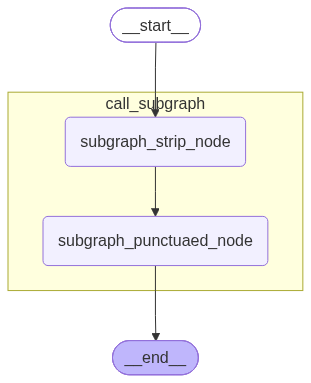

In [9]:
from IPython.display import display, Image

# display(parent_graph)
display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))

In [10]:
list(parent_graph.get_subgraphs())

[('call_subgraph',
  <langgraph.graph.state.CompiledStateGraph at 0x1347a988550>)]